# Logistic Regression (Baseline + Tuned) — Multiclass
This notebook trains Logistic Regression models for the multiclass **spend_category** target.

**What this notebook does**
- Loads preprocessed train/test files
- Trains a baseline Logistic Regression
- Improve using class weights
- Evaluates with accuracy, F1 (macro), classification report, and confusion matrix
- Runs a Grid Search to tune hyperparameters (regularization C, penalty/solver)
- Writes test predictions to `submission/` (file: `lr_submission.csv`)


### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score,f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import joblib
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning


os.makedirs("../models", exist_ok=True)
os.makedirs("../submissions", exist_ok=True)


### Load Datasets

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val   = pd.read_csv("../data/processed/X_val.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val   = pd.read_csv("../data/processed/y_val.csv").squeeze()

test = pd.read_csv("../data/processed/test.csv")
test_trip_id = pd.read_csv("../data/processed/test_trip_id.csv").squeeze()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", test.shape)
print("Target:", y_train.shape)

Train: (10096, 79)
Validation: (2524, 79)
Test: (5852, 79)
Target: (10096,)


### Train a baseline Logistic Regression.

In [3]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# ---------------------------
# Train model
# ---------------------------
logreg_base = LogisticRegression(
    multi_class="auto",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

logreg_base.fit(X_train, y_train)

# ---------------------------
# Validation predictions
# ---------------------------
val_preds_base = logreg_base.predict(X_val)

acc = accuracy_score(y_val, val_preds_base)
f1  = f1_score(y_val, val_preds_base, average="macro")

print("Baseline Logistic Regression Performance")
print("------------------------------------------")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1:.4f}\n")

print("🔎 Classification Report:")
print(classification_report(y_val, val_preds_base))

# ---------------------------
# Convergence check
# ---------------------------
try:
    if hasattr(logreg_base, "n_iter_") and any(i >= logreg_base.max_iter for i in logreg_base.n_iter_):
        print("\nNOTE: Model likely did NOT fully converge. (Hit max_iter)\n")
    else:
        print("\nModel converged successfully.\n")
except:
    # Some sklearn versions return a different structure
    print("\nCould not verify convergence, but training completed.\n")



# Save model
joblib.dump(logreg_base, "../models/logreg_baseline.joblib")

# Test predictions
test_preds_base = logreg_base.predict(test)

submission_base = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_base
})

submission_base.to_csv("../submissions/logreg_baseline.csv", index=False)

print("Baseline model saved and submission file generated.")

Baseline Logistic Regression Performance
------------------------------------------
Accuracy: 0.7401
F1 Macro: 0.6278

🔎 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1249
         1.0       0.66      0.74      0.70       982
         2.0       0.60      0.25      0.35       293

    accuracy                           0.74      2524
   macro avg       0.69      0.61      0.63      2524
weighted avg       0.73      0.74      0.73      2524


Model converged successfully.

Baseline model saved and submission file generated.


### Logistic Regression with Class Weights

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# ---------------------------
# Train model
# ---------------------------
logreg_balanced = LogisticRegression(
    multi_class="auto",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=3000,
    n_jobs=-1
)

logreg_balanced.fit(X_train, y_train)

# ---------------------------
# Validation performance
# ---------------------------
val_preds_balanced = logreg_balanced.predict(X_val)

acc_bal = accuracy_score(y_val, val_preds_balanced)
f1_bal  = f1_score(y_val, val_preds_balanced, average="macro")

print("Logistic Regression with Class Weights (Balanced)")
print("---------------------------------------------------")
print(f"Accuracy: {acc_bal:.4f}")
print(f"F1 Macro: {f1_bal:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_balanced))

# ---------------------------
# Check convergence
# ---------------------------
try:
    if hasattr(logreg_balanced, "n_iter_") and any(i >= logreg_balanced.max_iter for i in logreg_balanced.n_iter_):
        print("\nNOTE: Weighted model did NOT fully converge. (Reached max_iter)\n")
    else :
        print("\nModel converged successfully.\n")
except:
    print("\nCould not verify convergence, but training completed.\n")


os.makedirs("../models", exist_ok=True)
os.makedirs("../submissions", exist_ok=True)

# Save model
joblib.dump(logreg_balanced, "../models/logreg_balanced.joblib")

# Test predictions
test_preds_balanced = logreg_balanced.predict(test)

submission_balanced = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_balanced
})

submission_balanced.to_csv("../submissions/logreg_balanced.csv", index=False)

print("Balanced model saved and submission generated.")

Logistic Regression with Class Weights (Balanced)
---------------------------------------------------
Accuracy: 0.6862
F1 Macro: 0.6316

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84      1249
         1.0       0.67      0.48      0.56       982
         2.0       0.37      0.74      0.49       293

    accuracy                           0.69      2524
   macro avg       0.63      0.69      0.63      2524
weighted avg       0.72      0.69      0.69      2524


NOTE: Weighted model did NOT fully converge. (Reached max_iter)

Balanced model saved and submission generated.


### Hyperparameter Tuning using GridSearchCV

In [7]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ===== SAFE parameter grid =====
# Only combinations that sklearn actually supports
param_grid = {
    "C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "solver": ["lbfgs", "saga"],
    "penalty": ["l2"],
    "max_iter": [1500, 3000],
    "tol": [1e-4, 5e-4]
}

logreg_hp = LogisticRegression(
    multi_class="auto",
    class_weight="balanced",
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=logreg_hp,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    error_score="raise"  # fail fast instead of masking errors
)

grid.fit(X_train, y_train)

print("\nBest Hyperparameters Found:")
print(grid.best_params_)
print(f"Best CV Score (F1 Macro): {grid.best_score_:.4f}")

best_logreg = grid.best_estimator_
val_preds_hp = best_logreg.predict(X_val)

acc_hp = accuracy_score(y_val, val_preds_hp)
f1_hp  = f1_score(y_val, val_preds_hp, average="macro")

print("\nTuned Logistic Regression Performance")
print("----------------------------------------")
print(f"Accuracy: {acc_hp:.4f}")
print(f"F1 Macro: {f1_hp:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_hp))

try:
    if hasattr(best_logreg, "n_iter_") and any(i >= best_logreg.max_iter for i in best_logreg.n_iter_):
        print("\nNOTE: Tuned model did NOT fully converge. (Reached max_iter)\n")
    else:
        print("\nTuned model converged successfully.\n")
except:
    print("\nCould not verify convergence, but training completed.\n")

joblib.dump(best_logreg, "../models/logreg_gridsearch.joblib")

test_preds_hp = best_logreg.predict(test)

submission_hp = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_hp
})

submission_hp.to_csv("../submissions/logreg_gridsearch.csv", index=False)

print("Tuned Logistic Regression saved and submission generated.")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Hyperparameters Found:
{'C': 0.5, 'max_iter': 1500, 'penalty': 'l2', 'solver': 'saga', 'tol': 0.0005}
Best CV Score (F1 Macro): 0.6177

Tuned Logistic Regression Performance
----------------------------------------
Accuracy: 0.6854
F1 Macro: 0.6329

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83      1249
         1.0       0.67      0.49      0.56       982
         2.0       0.38      0.75      0.50       293

    accuracy                           0.69      2524
   macro avg       0.63      0.69      0.63      2524
weighted avg       0.72      0.69      0.69      2524


Tuned model converged successfully.

Tuned Logistic Regression saved and submission generated.


### ElasticNet GridSearch

In [8]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

param_grid_elastic = {
    "solver": ["saga"],              # ONLY saga
    "penalty": ["elasticnet"],       # ONLY elasticnet
    "C": [0.1, 0.5, 1.0, 2.0],
    "l1_ratio": [0.25, 0.5, 0.75],   # 0–1 mix strength
    "max_iter": [3000, 6000],
    "tol": [1e-4]
}

logreg_elastic = LogisticRegression(
    multi_class="auto",
    class_weight="balanced",
    n_jobs=-1
)

grid_elastic = GridSearchCV(
    estimator=logreg_elastic,
    param_grid=param_grid_elastic,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    error_score="raise"
)

grid_elastic.fit(X_train, y_train)

print("\nBest ElasticNet Hyperparameters:")
print(grid_elastic.best_params_)
print(f"Best CV F1 Macro: {grid_elastic.best_score_:.4f}")

best_elastic = grid_elastic.best_estimator_
val_preds_elastic = best_elastic.predict(X_val)

acc_el = accuracy_score(y_val, val_preds_elastic)
f1_el  = f1_score(y_val, val_preds_elastic, average="macro")

print("\nElasticNet Logistic Regression Performance")
print("---------------------------------------------")
print(f"Accuracy: {acc_el:.4f}")
print(f"F1 Macro: {f1_el:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds_elastic))

try:
    if hasattr(best_logreg, "n_iter_") and any(i >= best_logreg.max_iter for i in best_logreg.n_iter_):
        print("\nNOTE: Tuned model did NOT fully converge. (Reached max_iter)\n")
    else:
        print("\nTuned model converged successfully.\n")
except:
    print("\nCould not verify convergence, but training completed.\n")

joblib.dump(best_elastic, "../models/logreg_elasticnet.joblib")

test_preds_elastic = best_elastic.predict(test)

submission_elastic = pd.DataFrame({
    "trip_id": test_trip_id,
    "spend_category": test_preds_elastic
})

submission_elastic.to_csv("../submissions/logreg_elasticnet.csv", index=False)

print("ElasticNet model saved & submission created.")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best ElasticNet Hyperparameters:
{'C': 0.5, 'l1_ratio': 0.75, 'max_iter': 3000, 'penalty': 'elasticnet', 'solver': 'saga', 'tol': 0.0001}
Best CV F1 Macro: 0.6185

ElasticNet Logistic Regression Performance
---------------------------------------------
Accuracy: 0.6854
F1 Macro: 0.6316

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.83      0.84      1249
         1.0       0.67      0.48      0.56       982
         2.0       0.38      0.74      0.50       293

    accuracy                           0.69      2524
   macro avg       0.63      0.69      0.63      2524
weighted avg       0.72      0.69      0.69      2524


Tuned model converged successfully.

ElasticNet model saved & submission created.


### Model Comparison 


📌 Logistic Regression Model Comparison
--------------------------------------
        model  accuracy  f1_macro
  Baseline LR  0.740095  0.627814
  Balanced LR  0.686212  0.631616
GridSearch LR  0.685420  0.632906
ElasticNet LR  0.685420  0.631588


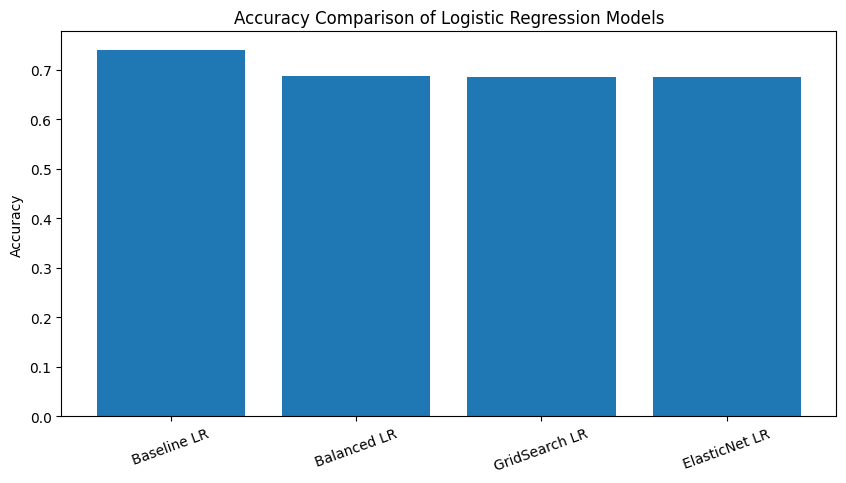

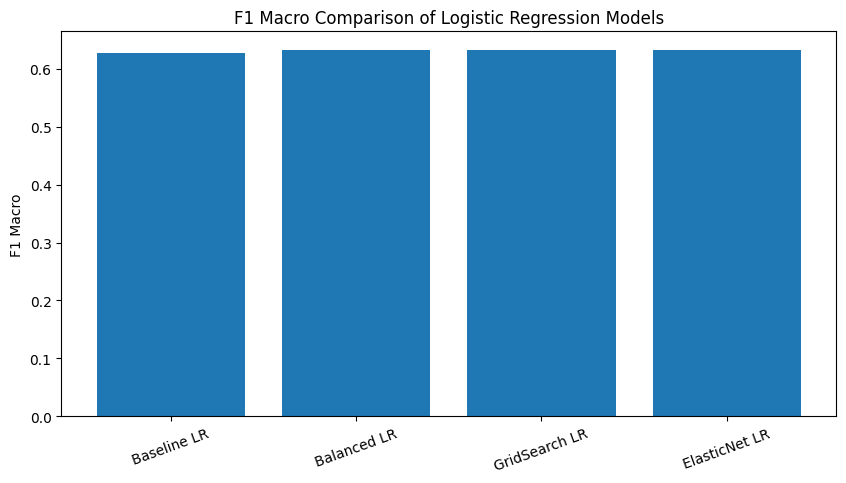

In [9]:
comparison = pd.DataFrame({
    "model": [
        "Baseline LR",
        "Balanced LR",
        "GridSearch LR",
        "ElasticNet LR"
    ],
    "accuracy": [
        accuracy_score(y_val, val_preds_base),
        accuracy_score(y_val, val_preds_balanced),
        accuracy_score(y_val, val_preds_hp),
        accuracy_score(y_val, val_preds_elastic)
    ],
    "f1_macro": [
        f1_score(y_val, val_preds_base, average="macro"),
        f1_score(y_val, val_preds_balanced, average="macro"),
        f1_score(y_val, val_preds_hp, average="macro"),
        f1_score(y_val, val_preds_elastic, average="macro")
    ]
})

comparison

print("\n📌 Logistic Regression Model Comparison")
print("--------------------------------------")
print(comparison.to_string(index=False))

plt.figure(figsize=(10,5))
plt.bar(comparison["model"], comparison["accuracy"])
plt.title("Accuracy Comparison of Logistic Regression Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(comparison["model"], comparison["f1_macro"])
plt.title("F1 Macro Comparison of Logistic Regression Models")
plt.ylabel("F1 Macro")
plt.xticks(rotation=20)
plt.show()

